In [1]:
import numpy as np
import cvxpy as cp
from scipy.stats import norm
import scipy

K = 1000
t0 = cp.Parameter(K, nonneg=True)
delta = cp.Variable(K)
x = np.linspace(0, 1, K)
eps = 0.2
c_bar = 0.3

eps_prime = cp.Parameter(1, nonneg=True)
f = cp.Parameter(K, nonneg=True)

def error_prob(c_bar, t):
   res = scipy.integrate.simps(norm.cdf(c_bar - t - np.linspace(0, 1, K)), np.linspace(0, 1, K))
   return res

def h(c_bar, t, delta):
    res = scipy.integrate.simps(delta * norm.pdf(c_bar - t - np.linspace(0, 1, K)), np.linspace(0, 1, K))
    return res
 

obj = cp.Minimize(cp.sum(t0 + delta) * (1/K))
constraints = [ t0 + delta >= 0, (-f @ delta) * (1/K) <= eps_prime]
prob = cp.Problem(obj, constraints)

M = 100
t0.value = np.ones(K) * 1.5
eps_prime.value = np.array([eps - error_prob(c_bar, t0.value)])
f.value = norm.pdf(-x)

costs = []
error_ps = []
etas = []

def backtracking_line_search(t_prev, delta, alpha=0.1, beta=0.9):
    eta = 1.
    while error_prob(c_bar, t_prev + eta * delta) > eps:
        eta *= beta
    return eta

In [2]:
for i in range(M):
    prob.solve()
    cost = prob.value
#     print("hi")
   
    eta = backtracking_line_search(t0.value, delta.value)
    t = t0.value + eta * delta.value
    error_p = error_prob(c_bar, t)
    costs.append(cost)
    error_ps.append(error_p)
    etas.append(eta)
#     print(delta.value)
    #update parameters
    t0.value = t
    f.value = norm.pdf(c_bar - t - x)
    eps_prime.value = np.array([np.maximum(eps - error_p, 0)])
    
#print(costs)
#print(error_ps)
#print(etas)
print(t)

/home/groups/swager/rsahoo/miniconda3/envs/cvxpy_env/lib/python3.9/site-packages/cvxpy/problems/problem.py:1385: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


[36.78591588 36.65201539 36.25032046 35.58085355 34.64366121 33.4388272
 31.96648967 30.22686153 28.22025317 25.94709717 23.40797497 20.60364963
 17.53511053 14.20360338 10.61100716  6.76012956  2.6568346  33.02500386
 25.63134716  1.86861354  1.39563772  0.92727905  1.23465366  4.5791147
  1.85191535  0.76555652  0.70849219  0.69998512  0.69924732  0.73611197
  0.69693025  0.69604172  0.69582878  0.69417992  0.69380013  0.69347238
  0.69127408  0.69078175  0.68911806  0.68817856  0.68676426  0.68741254
  0.68630195  0.68391977  0.68316045  0.68273961  0.68267484  0.68020944
  0.67963804  0.67801067  0.6782299   0.67604884  0.67484252  0.67393068
  0.67310057  0.67283202  0.6708401   0.66990505  0.67016446  0.66812996
  0.66685775  0.66695682  0.66532675  0.66406747  0.66275292  0.66387281
  0.66083019  0.6611498   0.65980274  0.65782604  0.65676771  0.6571608
  0.65482106  0.65449643  0.65344257  0.65233812  0.65141029  0.65097374
  0.64879285  0.64833778  0.6479744   0.64620927  0.64

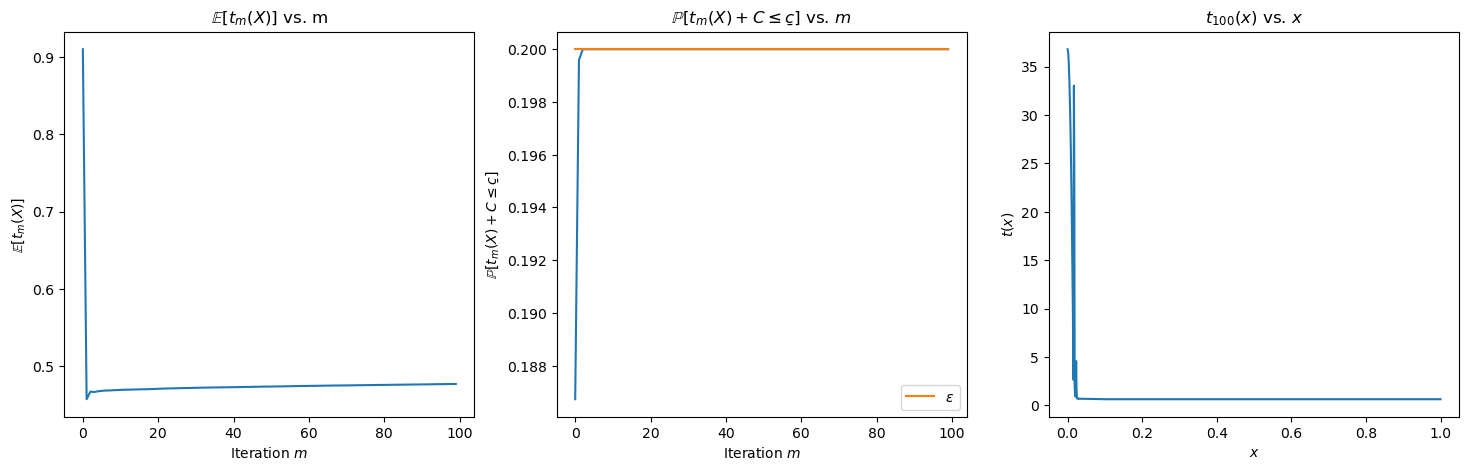

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[2].plot(x, t)
ax[2].set_xlabel(r"$x$")
ax[2].set_ylabel(r"$t(x)$")
ax[2].set_title(r"$t_{100}(x)$" + " vs. " + r"$x$")
ax[0].plot(list(range(M)), costs)
ax[0].set_ylabel(r"$\mathbb{E}[t_{m}(X)]$")
ax[0].set_title(r"$\mathbb{E}[t_{m}(X)]$" + " vs. m")
ax[0].set_xlabel("Iteration " + r"$m$")
ax[1].set_xlabel("Iteration " + r"$m$")
ax[1].plot(list(range(M)), error_ps)
ax[1].plot(list(range(M)), eps * np.ones(len(error_ps)), label=r"$\epsilon$")
ax[1].legend()
ax[1].set_ylabel(r"$\mathbb{P}[t_{m}(X) + C \leq c\underbar]$")
ax[1].set_title(r"$\mathbb{P}[t_{m}(X) + C \leq c\underbar]$" + " vs. " + r"$m$")
plt.savefig("linearized_optimization_linesearch.pdf", bbox_inches="tight")